
EDA: Viral Posts by Platform (VK vs TG)
Explore drivers of `is_viral` by platform on social_wide_final.csv.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import pipeline
from tqdm import tqdm

In [2]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
%matplotlib inline

In [3]:
DATA_DIR = Path("../data/processed")
FINAL_CSV = DATA_DIR / "social_wide_final.csv"
CLEAN_CSV = DATA_DIR / "social_clean.csv"
SAVE_DIR = Path("eda_outputs")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
read_kwargs = dict(
    low_memory=False,
    dtype={
        "is_ad": "string",
        "image_url": "string",
        "tg_is_forwarded": "string",
        "tg_fwd_src_name": "string",
    },
)


In [5]:
df = pd.read_csv(FINAL_CSV, **read_kwargs)
print(f"Loaded: {df}  rows={len(df):,}, cols={df.shape[1]}")
df.head(3)

Loaded:       platform        source_name                  source_link  followers   post_id               published_at  \
0           vk      Рифмы и Панчи  https://vk.com/club28905875    5500636  35113066                 1748947178   
1           vk      Рифмы и Панчи  https://vk.com/club28905875    5500636  35116660                 1748947178   
2           vk      Рифмы и Панчи  https://vk.com/club28905875    5500636  35116548                 1748947178   
3           vk      Рифмы и Панчи  https://vk.com/club28905875    5500636  35116157                 1748947178   
4           vk      Рифмы и Панчи  https://vk.com/club28905875    5500636  35116040                 1748947178   
...        ...                ...                          ...        ...       ...                        ...   
18520       tg  Банкофф - Финансы        https://t.me/bankoffo     180022     36630  2025-08-01T17:01:06+00:00   
18521       tg  Банкофф - Финансы        https://t.me/bankoffo     180022     36

,platform,source_name,source_link,followers,post_id,published_at,text,text_len,has_photo,has_video,has_link,has_poll,is_ad,link,vk_group_id,vk_from_id,image_url,likes,comments,reposts,likes_2025-06-07,reposts_2025-06-07,comments_2025-06-07,tg_channel_id,tg_channel_username,tg_is_forwarded,tg_fwd_src_id,tg_fwd_src_name,tg_fwd_src_msg_id,likes_2025-08-15,comments_2025-08-15,reposts_2025-08-15,collected_at_2025-08-15,original_collected_at_2025-08-15,original_comments_2025-08-15,original_likes_2025-08-15,original_reposts_2025-08-15,er_2025-06-07,er_2025-08-15,engagement_rate,er_final,emojis,num_emojis,num_hashtags,num_mentions,is_ad_by_text,clean_text,lemma_text,is_ad_final,published_at_dt,hour_posted,dow_posted,is_weekend,likes_pf,comments_pf,reposts_pf,engagement_change,len_text,emojis_per_100_chars,hashtags_per_100_chars,mentions_per_100_chars,log_followers,is_forwarded,has_fwd_src,has_fwd_msg_id,is_viral
0,vk,Рифмы и Панчи,https://vk.com/club28905875,5500636,35113066,1748947178,☄ ИИ НАПИШЕТ ДИПЛОМ ЗА ВАС! Собрали большую шп...,182,True,True,True,True,True,https://vk.com/club28905875,28905875.0,-28905875.0,https://sun9-15.userapi.com/s/v1/ig2/9Mogdi0ir...,300.0,1.0,613.0,474.0,880.0,1.0,NaN,NaN,<NA>,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000160,NaN,0.000111,0.000160,☄ 👇,2,0,0,False,ии напишет диплом за вас! собрали большую шпор...,ия написать диплом вас! собрать больший шпор т...,1,2025-06-03 10:39:38,10.0,1.0,0,0.000055,1.817972e-07,0.000111,0.000049,182,1.098901,0.0,0.0,15.520374,False,0,0,0
1,vk,Рифмы и Панчи,https://vk.com/club28905875,5500636,35116660,1748947178,В ROSTIC`S ЗАВЕЗЛИ ТАЙСКОЕ МЕНЮ — летние новин...,423,True,True,True,True,True,https://vk.com/club28905875,28905875.0,-28905875.0,https://sun9-45.userapi.com/s/v1/if2/VAggYdyZT...,36.0,4.0,169.0,350.0,1490.0,17.0,NaN,NaN,<NA>,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000271,NaN,0.000031,0.000271,➖ 🤨 😮,3,0,0,False,в завезли тайское меню летние новинки уже можн...,завезти тайский меню летний новинка попробоват...,1,2025-06-03 10:39:38,10.0,1.0,0,0.000007,7.271886e-07,0.000031,0.000240,423,0.709220,0.0,0.0,15.520374,False,0,0,0
2,vk,Рифмы и Панчи,https://vk.com/club28905875,5500636,35116548,1748947178,Рабочий день обязаны сократить до 4-х часов пр...,604,True,True,True,True,True,https://vk.com/club28905875,28905875.0,-28905875.0,https://sun9-68.userapi.com/s/v1/if2/aPsqeBaiD...,147.0,11.0,250.0,627.0,1139.0,28.0,NaN,NaN,<NA>,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000207,NaN,0.000045,0.000207,🥵 ➖ 👨‍💻,3,0,0,False,рабочий день обязаны сократить до 4-х часов пр...,рабочий день обязать сократить 4-й час жара вы...,1,2025-06-03 10:39:38,10.0,1.0,0,0.000027,1.999769e-06,0.000045,0.000162,604,0.496689,0.0,0.0,15.520374,False,0,0,0


In [6]:
print("=== BASIC DATA INFORMATION ===")
print(f"Dataset shape: {df.shape}")
print(f"Viral posts count: {df['is_viral'].sum()} ({df['is_viral'].mean()*100:.2f}%)")
print(f"Missing values:\\n{df.isnull().sum().sort_values(ascending=False).head(10)}")

=== BASIC DATA INFORMATION ===
Dataset shape: (18525, 66)
Viral posts count: 1854 (10.01%)
Missing values:\ntg_fwd_src_name                     18523
original_comments_2025-08-15        18466
original_likes_2025-08-15           18460
tg_fwd_src_msg_id                   18420
tg_fwd_src_id                       18419
original_reposts_2025-08-15         18404
collected_at_2025-08-15             18404
original_collected_at_2025-08-15    18404
comments_2025-08-15                 15860
likes_2025-08-15                    13941
dtype: int64


In [7]:
# 2. Platform distribution
print("\\n=== PLATFORM DISTRIBUTION ===")
platform_dist = df['platform'].value_counts()
print(platform_dist)
print(f"\\nVirality rate by platform:")
print(df.groupby('platform')['is_viral'].mean())

\n=== PLATFORM DISTRIBUTION ===
platform
vk    11823
tg     6702
Name: count, dtype: int64
\nVirality rate by platform:
platform
tg    0.100119
vk    0.100059
Name: is_viral, dtype: float64


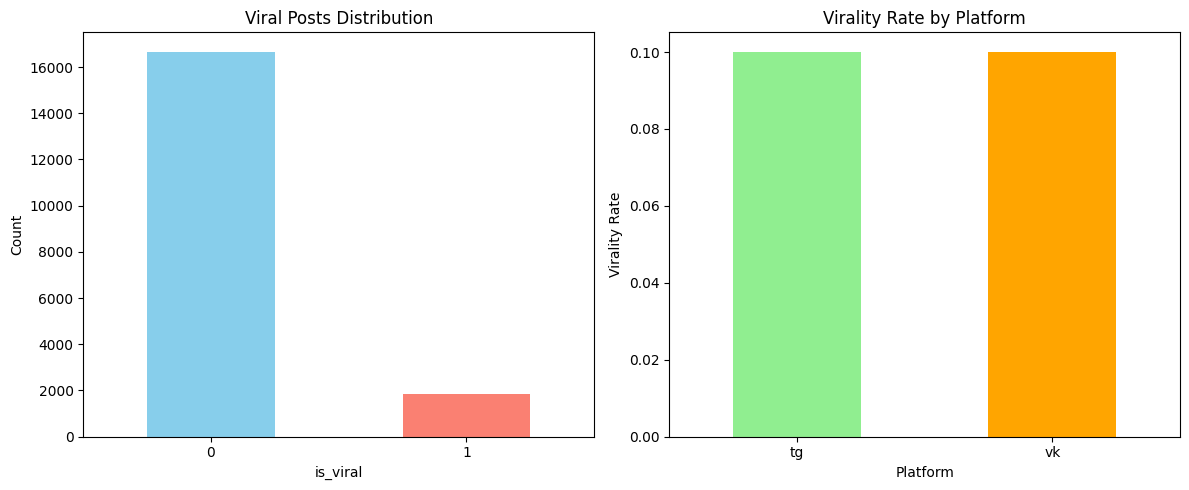

In [9]:
# 3. Target variable visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['is_viral'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Viral Posts Distribution')
plt.xlabel('is_viral')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df.groupby('platform')['is_viral'].mean().plot(kind='bar', color=['lightgreen', 'orange'])
plt.title('Virality Rate by Platform')
plt.xlabel('Platform')
plt.ylabel('Virality Rate')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


In [10]:
# 4. Numerical features analysis
print("\\n=== NUMERICAL FEATURES ANALYSIS ===")
numeric_cols = ['followers', 'text_len', 'likes_pf', 'comments_pf', 'reposts_pf', 
                'engagement_change', 'emojis_per_100_chars', 'log_followers']

print(df[numeric_cols].describe())

\n=== NUMERICAL FEATURES ANALYSIS ===
          followers      text_len      likes_pf   comments_pf    reposts_pf  engagement_change  emojis_per_100_chars  log_followers
count  1.852500e+04  18525.000000  18525.000000  18525.000000  18525.000000       1.852500e+04          18525.000000   18525.000000
mean   2.536412e+06    313.287395      0.002397      0.000052      0.000787       9.711166e-06              0.892948      14.308725
std    2.556395e+06    516.051866      0.008018      0.000315      0.001704       1.041798e-04              3.739349       1.033428
min    1.014890e+05      1.000000      0.000000      0.000000      0.000000      -8.185219e-04              0.000000      11.527716
25%    1.252482e+06     46.000000      0.000051      0.000000      0.000027       0.000000e+00              0.000000      14.040639
50%    1.904821e+06    140.000000      0.000297      0.000003      0.000156       0.000000e+00              0.000000      14.459899
75%    3.042195e+06    376.000000     

In [11]:
# 5. Correlation analysis
print("\\n=== CORRELATION WITH TARGET VARIABLE ===")
correlation_with_target = df[numeric_cols + ['is_viral']].corr()['is_viral'].sort_values(ascending=False)
print(correlation_with_target)

\n=== CORRELATION WITH TARGET VARIABLE ===
is_viral                1.000000
reposts_pf              0.602700
engagement_change       0.138988
likes_pf                0.129319
comments_pf             0.060698
emojis_per_100_chars   -0.022699
log_followers          -0.028938
followers              -0.057380
text_len               -0.085494
Name: is_viral, dtype: float64


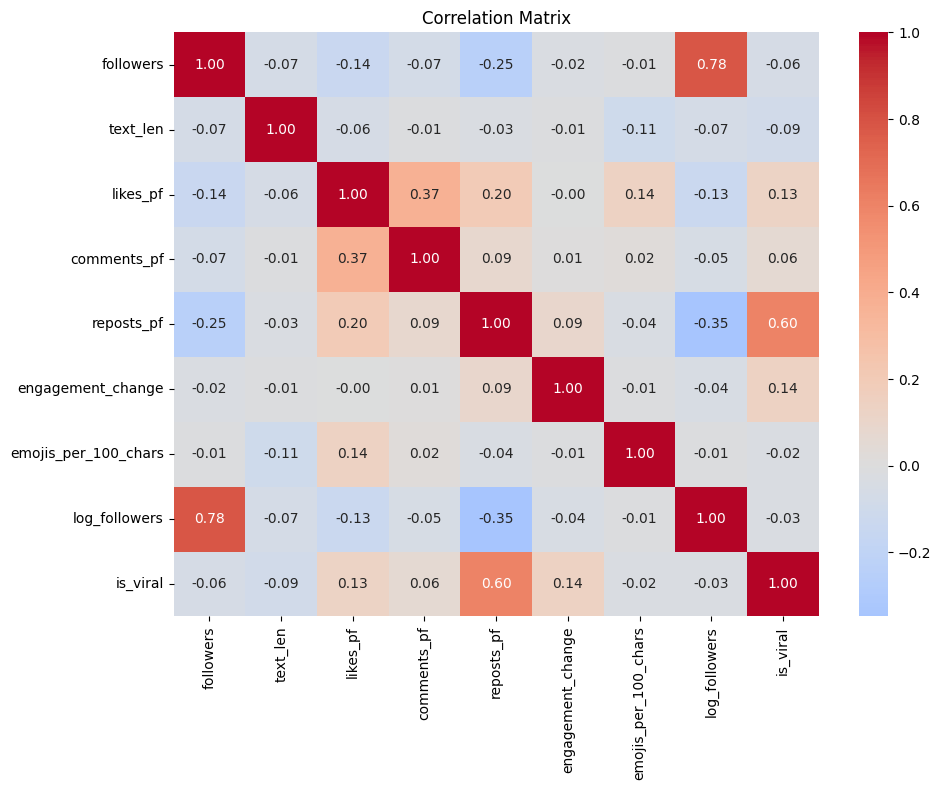

In [14]:
# 6. Correlation matrix visualization
plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols + ['is_viral']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# 7. Categorical features analysis
print("\\n=== CATEGORICAL FEATURES ANALYSIS ===")
categorical_cols = ['has_photo', 'has_video', 'has_link', 'has_poll', 'is_forwarded', 'is_weekend']

for col in categorical_cols:
    if col in df.columns:
        print(f"\\n{col}:")
        viral_rate = df.groupby(col)['is_viral'].mean()
        print(viral_rate)

\n=== CATEGORICAL FEATURES ANALYSIS ===
\nhas_photo:
has_photo
True    0.100081
Name: is_viral, dtype: float64
\nhas_video:
has_video
True    0.100081
Name: is_viral, dtype: float64
\nhas_link:
has_link
True    0.100081
Name: is_viral, dtype: float64
\nhas_poll:
has_poll
True    0.100081
Name: is_viral, dtype: float64
\nis_forwarded:
is_forwarded
False    0.100059
True     0.100119
Name: is_viral, dtype: float64
\nis_weekend:
is_weekend
0    0.100081
Name: is_viral, dtype: float64


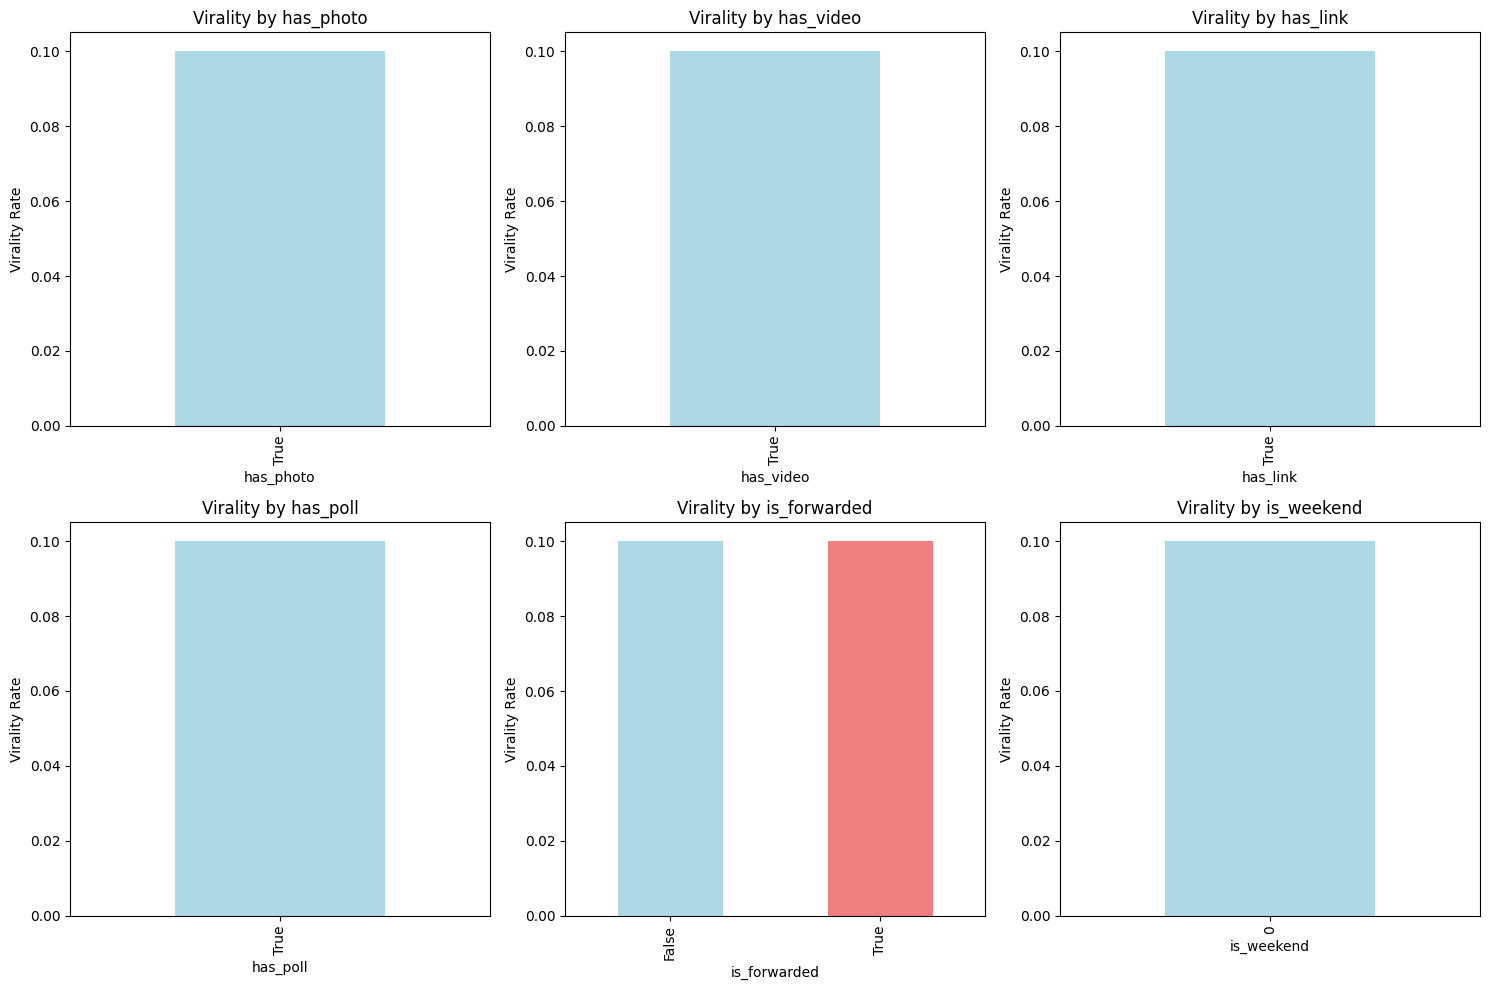

In [16]:
# 8. Categorical features visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    if col in df.columns:
        df.groupby(col)['is_viral'].mean().plot(kind='bar', ax=axes[i], color=['lightblue', 'lightcoral'])
        axes[i].set_title(f'Virality by {col}')
        axes[i].set_ylabel('Virality Rate')
        axes[i].set_xlabel(col)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'categorical_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

\n=== TEMPORAL FEATURES ANALYSIS ===


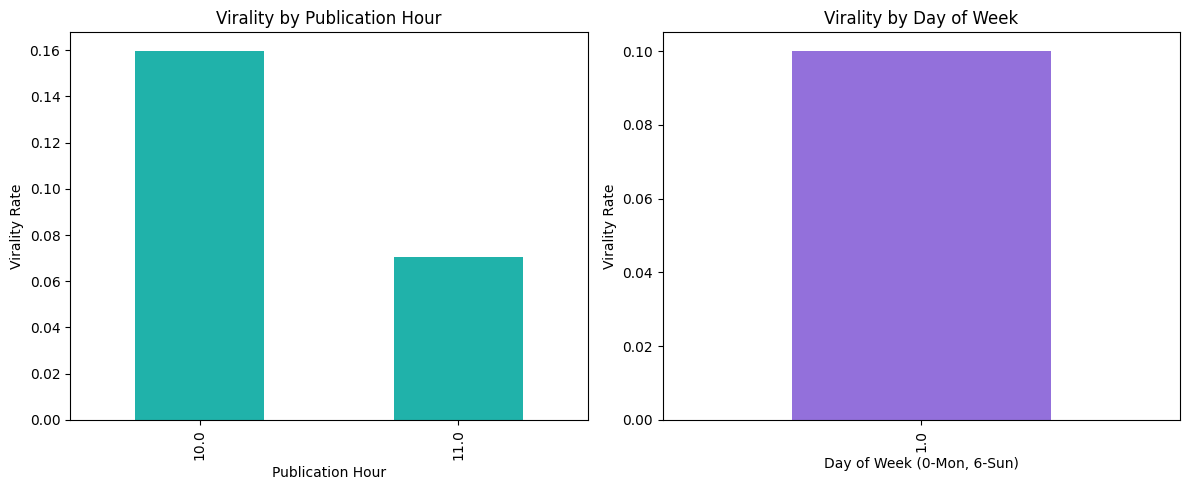

In [17]:
# 9. Temporal features analysis
print("\\n=== TEMPORAL FEATURES ANALYSIS ===")
if 'hour_posted' in df.columns:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    df.groupby('hour_posted')['is_viral'].mean().plot(kind='bar', color='lightseagreen')
    plt.title('Virality by Publication Hour')
    plt.xlabel('Publication Hour')
    plt.ylabel('Virality Rate')
    
    plt.subplot(1, 2, 2)
    df.groupby('dow_posted')['is_viral'].mean().plot(kind='bar', color='mediumpurple')
    plt.title('Virality by Day of Week')
    plt.xlabel('Day of Week (0-Mon, 6-Sun)')
    plt.ylabel('Virality Rate')
    
    plt.tight_layout()
    plt.savefig(SAVE_DIR / 'time_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

\n=== OUTLIERS ANALYSIS ===


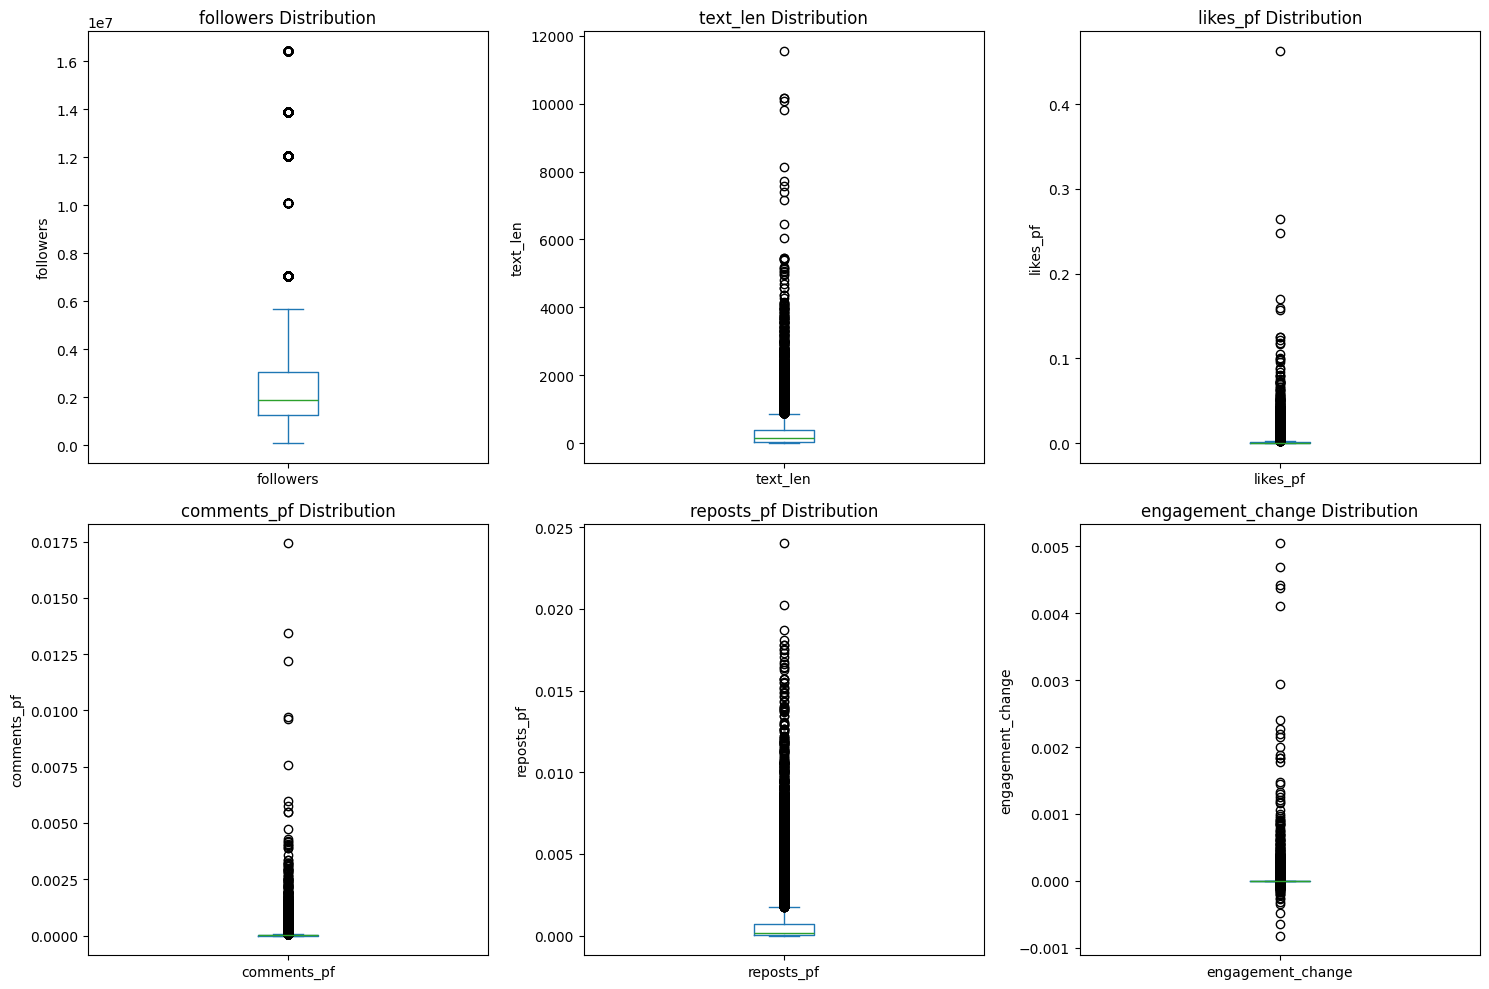

In [18]:
# 10. Outliers analysis
print("\\n=== OUTLIERS ANALYSIS ===")
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols[:6], 1):
    plt.subplot(2, 3, i)
    df[col].plot(kind='box')
    plt.title(f'{col} Distribution')
    plt.ylabel(col)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'outliers_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# 11. Platform comparison
print("\\n=== PLATFORM COMPARISON ===")
platform_comparison = df.groupby('platform').agg({
    'is_viral': 'mean',
    'likes_pf': 'median',
    'comments_pf': 'median',
    'reposts_pf': 'median',
    'text_len': 'median',
    'followers': 'median'
}).round(4)

print(platform_comparison)

\n=== PLATFORM COMPARISON ===
          is_viral  likes_pf  comments_pf  reposts_pf  text_len  followers
platform                                                                  
tg          0.1001    0.0008          0.0      0.0009     247.0   676627.0
vk          0.1001    0.0002          0.0      0.0001      91.0  2693516.0


In [3]:
# Пути
input_path = "../data/processed/enriched_sentiment_themes.csv"
# output_path = "../data/processed/enriched_sentiment_themes.csv"

# Загрузка датасета
df = pd.read_csv(input_path)
print(f"Исходный датасет: {df.shape}")

Исходный датасет: (18525, 106)


C:\Users\user\AppData\Local\Temp\ipykernel_13920\3801018765.py:6: DtypeWarning: Columns (5,12,16,24,25,27,32,33,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_path)


In [5]:
# Вывести названия всех колонок
print("Названия всех колонок:")
print(df.columns.tolist())

# Вывести типы данных всех колонок
print("\nТипы данных всех колонок:")
print(df.dtypes)

Названия всех колонок:
['platform', 'source_name', 'source_link', 'followers', 'post_id', 'published_at', 'text', 'text_len', 'has_photo', 'has_video', 'has_link', 'has_poll', 'is_ad', 'link', 'vk_group_id', 'vk_from_id', 'image_url', 'likes', 'comments', 'reposts', 'likes_2025-06-07', 'reposts_2025-06-07', 'comments_2025-06-07', 'tg_channel_id', 'tg_channel_username', 'tg_is_forwarded', 'tg_fwd_src_id', 'tg_fwd_src_name', 'tg_fwd_src_msg_id', 'likes_2025-08-15', 'comments_2025-08-15', 'reposts_2025-08-15', 'collected_at_2025-08-15', 'original_collected_at_2025-08-15', 'original_comments_2025-08-15', 'original_likes_2025-08-15', 'original_reposts_2025-08-15', 'er_2025-06-07', 'er_2025-08-15', 'engagement_rate', 'er_final', 'emojis', 'num_emojis', 'num_hashtags', 'num_mentions', 'is_ad_by_text', 'clean_text', 'lemma_text', 'is_ad_final', 'published_at_dt', 'hour_posted', 'dow_posted', 'is_weekend', 'likes_pf', 'comments_pf', 'reposts_pf', 'engagement_change', 'len_text', 'emojis_per_100

In [6]:
# Перечисленные проблемные индексы колонок
problem_indices = [5, 12, 16, 24, 25, 27, 32, 33, 49]

print("\nНазвание и типы проблемных колонок:")
for i in problem_indices:
    col_name = df.columns[i]
    col_type = df.dtypes[i]
    print(f"Индекс: {i}, Название: '{col_name}', Тип: {col_type}")


Название и типы проблемных колонок:
Индекс: 5, Название: 'published_at', Тип: object
Индекс: 12, Название: 'is_ad', Тип: object
Индекс: 16, Название: 'image_url', Тип: object
Индекс: 24, Название: 'tg_channel_username', Тип: object
Индекс: 25, Название: 'tg_is_forwarded', Тип: object
Индекс: 27, Название: 'tg_fwd_src_name', Тип: object
Индекс: 32, Название: 'collected_at_2025-08-15', Тип: object
Индекс: 33, Название: 'original_collected_at_2025-08-15', Тип: object
Индекс: 49, Название: 'published_at_dt', Тип: object


C:\Users\user\AppData\Local\Temp\ipykernel_11900\785660637.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  col_type = df.dtypes[i]
C:\Users\user\AppData\Local\Temp\ipykernel_11900\785660637.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  col_type = df.dtypes[i]
C:\Users\user\AppData\Local\Temp\ipykernel_11900\785660637.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  col_type = df.dtypes[i]
C:\Users\user\AppData\Local\Tem

In [6]:
# Остальные оставить строками (object)
df['image_url'] = df['image_url'].astype(str)
df['tg_channel_username'] = df['tg_channel_username'].astype(str)
df['tg_fwd_src_name'] = df['tg_fwd_src_name'].astype(str)

In [8]:
# Сначала преобразуем с ошибками в NaT (ошибка будет игнорирована)
df['published_at'] = pd.to_datetime(df['published_at'], errors='coerce')

df['collected_at_2025-08-15'] = pd.to_datetime(df['collected_at_2025-08-15'], errors='coerce', infer_datetime_format=True)

df['original_collected_at_2025-08-15'] = pd.to_datetime(df['original_collected_at_2025-08-15'], errors='coerce', infer_datetime_format=True)

df['published_at_dt'] = pd.to_datetime(df['published_at_dt'], errors='coerce')

# Если колонки имеют временную зону, убираем ее с помощью tz_localize(None)
for col in ['published_at', 'collected_at_2025-08-15', 'original_collected_at_2025-08-15', 'published_at_dt']:
    if df[col].dt.tz is not None:
        df[col] = df[col].dt.tz_localize(None)

# Преобразование типов bool - оставаем без изменений
df['is_ad'] = df['is_ad'].map({'True': True, 'False': False, True: True, False: False}).fillna(False).astype(bool)
df['tg_is_forwarded'] = df['tg_is_forwarded'].map({'True': True, 'False': False, True: True, False: False}).fillna(False).astype(bool)


ValueError: Cannot mix tz-aware with tz-naive values

C:\Users\user\AppData\Local\Temp\ipykernel_8252\999629125.py:3: DtypeWarning: Columns (5,12,24,25,27,32,33,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/enriched_with_images.csv")



Statistics for thematic features:

Statistics for thematic features:
politics: 2499 posts (13.5%) contain this theme
war: 1738 posts (9.4%) contain this theme
economy: 3311 posts (17.9%) contain this theme
ai_tech: 768 posts (4.1%) contain this theme
health: 2229 posts (12.0%) contain this theme
sports: 3604 posts (19.5%) contain this theme
education: 1322 posts (7.1%) contain this theme
crime: 810 posts (4.4%) contain this theme
religion: 1381 posts (7.5%) contain this theme


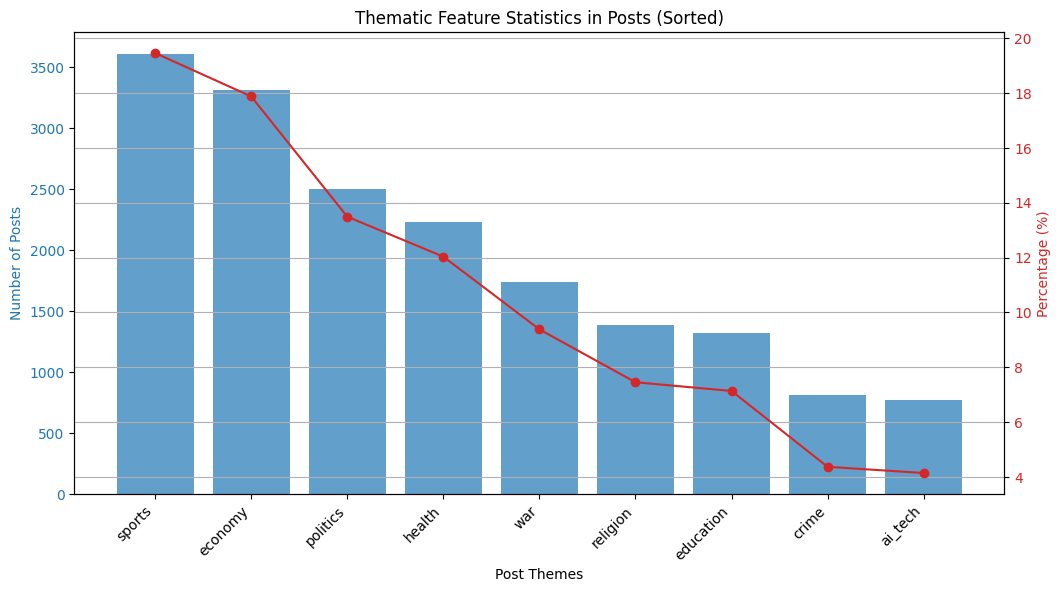

In [15]:
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/enriched_with_images.csv")

# Calculate counts and percentages for each theme
stats = {}

# 2) доменные лексиконы (минимальные seed-списки; расширяй под свою предметку)
LEX_CATS = {
    "politics": [
        "политик*", "политолог*", "власть*", "режим*", "госдум*", "совет федераци*", "парламент*",
        "депутат*", "министерств*", "ведомств*", "чиновник*", "губернатор*", "мэр*", "префект*",
        "закон*", "законопроект*", "инициатив*", "поправк*", "конституци*", "указ*", "постановлен*",
        "правительств*", "кабинет министров", "кремл*", "администрац* президент*", "силовик*",
        "оппозици*", "коалици*", "митинг*", "протест*", "пикет*", "санкци*", "эмбарг*",
        "выбор*", "кампани*", "агитаци*", "голосован*", "бюллетен*", "участок", "наблюдател*",
        "ци*", "центризбирком*", "партий*", "парти*", "блок*", "список*", "мандат*",
        "ЕС", "Евросоюз", "НАТО", "США", "ООН", "саммит*", "форум*", "декларац*",
    ],
    "war": [
        "войн*", "конфликт*", "боев*", "боестолкновен*", "эскалаци*", "мобилизац*", "демобилизац*",
        "призыв*", "контрактник*", "армия", "военнослужащ*", "фронт*", "линия обороны", "оккуп*",
        "наступлен*", "контрнаступлен*", "оборон*", "позици*", "штурм*", "обстрел*", "артобстрел*",
        "удар*", "ракет*", "снаряд*", "дрон*", "бпла", "авиаудар*", "бомбардир*", "миномет*",
        "потер*", "ранен*", "погиб*", "эвакуац*", "гуманитарн*", "плен*", "перемир*", "капитуляц*",
        "минобороны", "МО РФ", "ВС РФ", "ВСУ", "НАТО", "бригада*", "батальон*", "рота*",
    ],
    "economy": [
        "экономик*", "макро*", "инфляци*", "дефляци*", "рецесси*", "восстановлен*",
        "ввп", "валов* продукт*", "промышленност*", "розниц*", "торговл*",
        "курс", "рубл*", "доллар*", "евр*", "юан*", "бирж*", "индекс*", "мосбирж*",
        "акци*", "облигац*", "бонд*", "дивиденд*", "инвестиц*", "портфел*", "доходност*",
        "бюджет*", "дефицит*", "профицит*", "налог*", "ндс", "ндфл", "страхов*", "пошлин*",
        "зарплат*", "пенси*", "безработиц*", "рынок труд*", "кредит*", "ипотек*", "ставк*",
        "цб", "ключев* ставк*", "банк*", "банкротств*", "санкци*", "экспорт*", "импорт*",
        "нефть*", "газ*", "угл*", "энерг*", "тариф*", "субсиди*", "монопол*", "конкуренц*",
    ],
    "ai_tech": [
        "искусственн* интеллек*", "ИИ", "нейросет*", "машинн* обучен*", "глубок* обучен*", "transfer learn*",
        "трансформер*", "эмбеддинг*", "векторн* баз*", "retrieval", "RAG", "агент*", "автономн* агент*",
        "LLM", "GPT", "ChatGPT", "Gemini", "Claude", "LLaMA", "Mistral", "GigaChat", "SberGPT",
        "dataset*", "датасет*", "корпус*", "разметк*", "fine-tun*", "дообучен*", "инференс*", "генерац*",
        "NLP", "NLU", "CV", "ASR", "TTS", "LLMOps", "MLOps", "pipeline*", "пайплайн*",
        "PyTorch", "TensorFlow", "Keras", "scikit-learn", "Hugging Face", "OpenAI",
    ],
    "health": [
        "здоров*", "здравоохранен*", "минздрав", "врач*", "медик*", "медсестр*", "фельдшер*",
        "клиник*", "госпитал*", "стационар*", "поликлиник*", "медучрежден*",
        "вакцин*", "прививк*", "иммунизац*", "эпидеми*", "пандем*", "коронавир*", "covid*",
        "грипп*", "орви", "симптом*", "диагноз*", "терап*", "хирург*", "реабилит*", "лекарств*",
        "препарат*", "аптек*", "ИВЛ", "санитар*", "скорая*", "психолог*", "психиатр*", "нарколог*",
    ],
    "sports": [
        "спорт*", "команд*", "сборн*", "тренер*", "игрок*", "форвард*", "защитник*", "нападающ*",
        "турнир*", "чемпионат*", "кубок*", "лига*", "сезон*", "раунд*", "плей-офф", "финал*",
        "матч*", "гол*", "пас*", "пенальт*", "офсайд*", "вар", "судья*", "тайм*", "таблиц*",
        "футбол*", "хоккей*", "баскетбол*", "теннис*", "волейбол*", "бокс*", "ММА", "UFC",
        "НХЛ", "НБА", "РПЛ", "УЕФА", "ФИФА", "формул* 1", "гран-при", "олимпиад*", "паралимпиад*",
    ],
    "education": [
        "образован*", "университет*", "институт*", "вуз*", "кафедр*", "декан*", "ректор*",
        "школ*", "лице*", "гимнази*", "колледж*", "техникум*", "курс*", "лекци*", "семинар*",
        "абитуриент*", "поступлен*", "зачёт*", "сесс*", "экзамен*", "егэ", "огэ",
        "бакалавр*", "магистр*", "аспирант*", "диссертаци*", "защит*", "диплом*",
        "стипенди*", "грант*", "учебник*", "методич*", "онлайн-курс*", "дистанционн* обучен*",
        "преподавател*", "учител*", "студент*", "родител*",
    ],
    "crime": [
        "преступлен*", "преступник*", "уголовн*", "уголовное дел*", "подозреваем*", "обвиняем*", "осуждён*",
        "следств*", "разыск*", "оперативник*", "задержан*", "арест*", "мер* пресечен*", "обыск*",
        "суд*", "приговор*", "апелляц*", "кассаци*", "адвокат*", "прокуратур*", "следком", "мвд", "фсб",
        "мошеннич*", "краж*", "грабёж", "разбой", "угон*", "вымогатель*", "взлом*", "киберпреступлен*",
        "убийств*", "нанесен* вред*", "наркотик*", "оборот наркот*", "контрабанд*", "коррупци*", "взятк*", "откат*",
        "отмывани* денег", "рейдерств*",
    ],
    "religion": [
        "религи*", "вера", "конфесс*", "церк*", "храм*", "собор*", "монастыр*",
        "священник*", "батюшк*", "патриарх*", "митрополит*", "епархи*", "литург*", "проповед*",
        "молитв*", "пост*", "таинств*", "пасх*", "рождеств*",
        "мечеть*", "имам*", "коран*", "хадж*", "умр*",
        "синагог*", "раввин*", "тора*", "косер*", "икон*",
    ],
}

print("\nStatistics for thematic features:")
import matplotlib.pyplot as plt

# Collect stats as before
stats = {}
for cat in LEX_CATS.keys():
    flag_col = f"lex_{cat}_flag"
    if flag_col in df.columns:
        count = df[flag_col].sum()
        perc = df[flag_col].mean() * 100
        stats[cat] = (count, perc)

print("\nStatistics for thematic features:")
for cat in LEX_CATS.keys():
    count_col = f"lex_{cat}_count"
    flag_col = f"lex_{cat}_flag"
    if flag_col in df.columns:
        count = df[flag_col].sum()
        perc = df[flag_col].mean() * 100
        stats[cat] = (count, perc)
        print(f"{cat}: {count} posts ({perc:.1f}%) contain this theme")

# Sort themes by count descending
sorted_stats = sorted(stats.items(), key=lambda x: x[1][0], reverse=True)

categories = [x[0] for x in sorted_stats]
counts = [x[1][0] for x in sorted_stats]
percentages = [x[1][1] for x in sorted_stats]

# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Post Themes')
ax1.set_ylabel('Number of Posts', color=color)
ax1.bar(categories, counts, color=color, alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(rotation=45, ha='right')

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Percentage (%)', color=color)
ax2.plot(categories, percentages, color=color, marker='o')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Thematic Feature Statistics in Posts (Sorted)')
plt.grid(axis='y')

plt.show()



In [16]:
# additional features 
# time of publication as a cycle

import numpy as np
df["hour_sin"] = np.sin(2*np.pi*df["hour_posted"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour_posted"]/24)
df["dow_sin"]  = np.sin(2*np.pi*df["dow_posted"]/7)
df["dow_cos"]  = np.cos(2*np.pi*df["dow_posted"]/7)

In [17]:
# content structure
import re
t = df["text"].fillna("").astype(str)
df["num_sentences"] = t.str.count(r"[.!?]")
df["num_exclaims"]  = t.str.count(r"!")
df["num_questions"] = t.str.count(r"\?")
df["caps_ratio"]    = t.apply(lambda s: sum(ch.isupper() for ch in s)/max(len(s),1))
df["digit_ratio"]   = t.apply(lambda s: sum(ch.isdigit() for ch in s)/max(len(s),1))
df["url_count"]     = t.str.count(r"https?://")

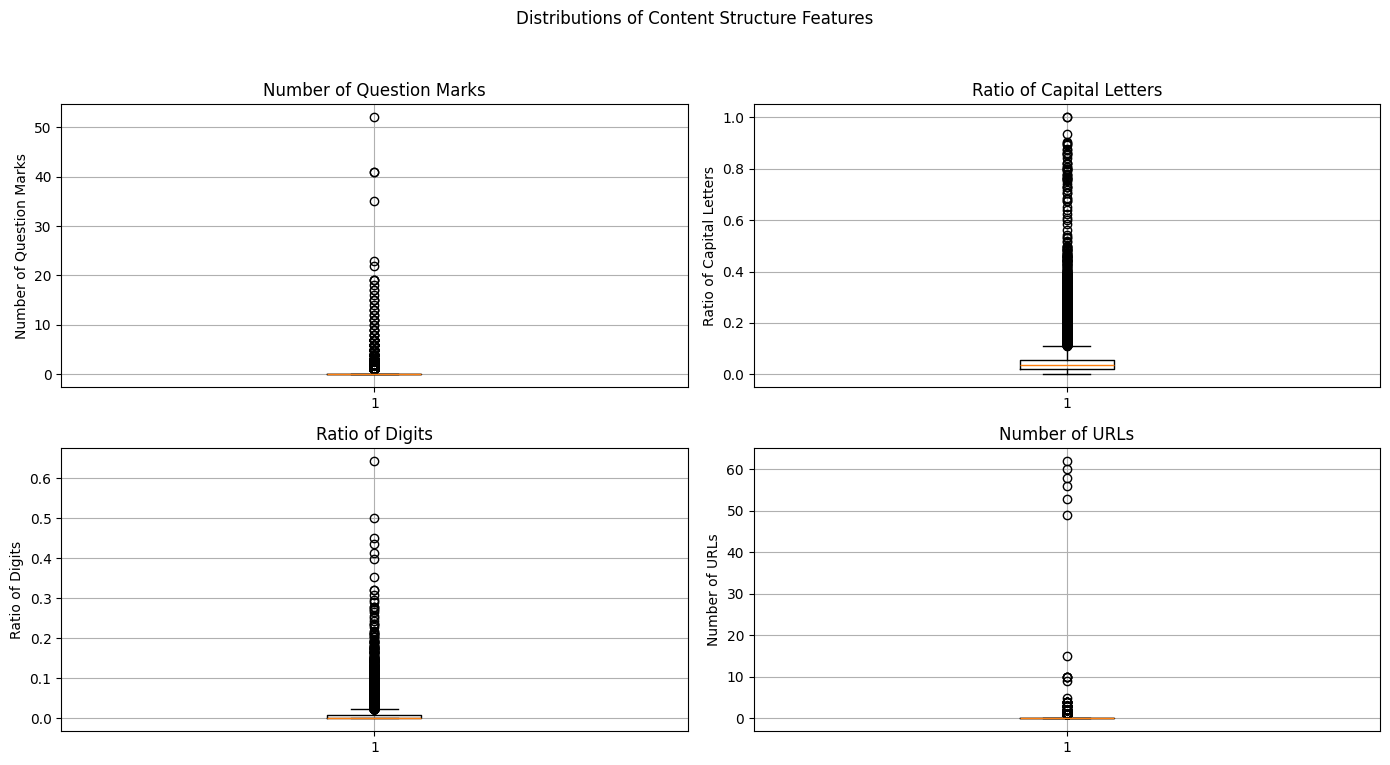

In [18]:
import matplotlib.pyplot as plt

features_to_plot = [
    ("num_questions", "Number of Question Marks"),
    ("caps_ratio", "Ratio of Capital Letters"),
    ("digit_ratio", "Ratio of Digits"),
    ("url_count", "Number of URLs")
]

plt.figure(figsize=(14, 8))

for i, (feature, title) in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    plt.boxplot(df[feature].replace([float('inf'), -float('inf')], 0).fillna(0))
    plt.title(title)
    plt.ylabel(title)
    plt.grid(True)

plt.suptitle("Distributions of Content Structure Features")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [2]:


# Пути
input_path = "../data/processed/enriched_sentiment_themes.csv"
output_path = "../data/processed/enriched_sentiment_themes.csv"

# Загрузка датасета
df = pd.read_csv(input_path)
print(f"Исходный датасет: {df.shape}")

# Инициализация модели классификации эмоций для русского языка
emotion_classifier = pipeline("text-classification", model="seara/rubert-base-cased-ru-go-emotions", return_all_scores=False)

# Выбор текстовой колонки для анализа
text_col = "text"

# Функция для предсказания эмоции
def predict_emotion(text):
    if pd.isna(text) or text.strip() == "":
        return "unknown"
    result = emotion_classifier(text[:512])  # ограничение длины для модели
    return result[0]['label']

# Применяем к столбцу текста с прогрессом
from tqdm import tqdm
tqdm.pandas()
df["emotion_type"] = df[text_col].progress_apply(predict_emotion)

# Сохраняем обновлённый датафрейм
df.to_csv(output_path, index=False, encoding='utf-8')
print(f"Датасет с тематическими фичами и колонкой эмоций сохранён: {output_path}")
print(f"Финальный размер датасета: {df.shape}")


C:\Users\user\AppData\Local\Temp\ipykernel_5056\2351823619.py:6: DtypeWarning: Columns (5,12,16,24,25,27,32,33,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_path)


Исходный датасет: (18525, 105)


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/712M [00:00<?, ?B/s]

c:\Users\user\Desktop\Final_LU\venv\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\models--seara--rubert-base-cased-ru-go-emotions. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Device set to use cpu
c:\Users\user\Desktop\Final_LU\venv\lib\site-packages\transformers\pipelines\text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
100%|██████████| 18525/18525 [29:01<00:00, 10.64it/s] 


Датасет с тематическими фичами и колонкой эмоций сохранён: ../data/processed/enriched_sentiment_themes.csv
Финальный размер датасета: (18525, 106)


In [4]:
# Подсчет статистики по колонке с эмоциями
emotion_counts = df["emotion_type"].value_counts(dropna=False)
emotion_ratios = df["emotion_type"].value_counts(normalize=True, dropna=False)

print("\nСтатистика по колонке 'emotion_type':")
for emotion, count in emotion_counts.items():
    ratio = emotion_ratios[emotion]
    print(f"{emotion}: {count} постов ({ratio*100:.2f}%)")


Статистика по колонке 'emotion_type':
neutral: 9946 постов (53.69%)
admiration: 2480 постов (13.39%)
curiosity: 1427 постов (7.70%)
optimism: 1214 постов (6.55%)
gratitude: 869 постов (4.69%)
caring: 468 постов (2.53%)
approval: 434 постов (2.34%)
love: 367 постов (1.98%)
joy: 290 постов (1.57%)
surprise: 167 постов (0.90%)
amusement: 159 постов (0.86%)
sadness: 152 постов (0.82%)
annoyance: 121 постов (0.65%)
excitement: 92 постов (0.50%)
desire: 67 постов (0.36%)
anger: 65 постов (0.35%)
disappointment: 65 постов (0.35%)
disapproval: 57 постов (0.31%)
disgust: 33 постов (0.18%)
confusion: 24 постов (0.13%)
fear: 15 постов (0.08%)
realization: 9 постов (0.05%)
remorse: 4 постов (0.02%)


In [5]:
df = pd.read_csv("../data/processed/enriched_with_images.csv")

# Подсчет статистики по колонке с эмоциями
emotion_counts = df["emotion_type_2"].value_counts(dropna=False)
emotion_ratios = df["emotion_type_2"].value_counts(normalize=True, dropna=False)

print("\nСтатистика по колонке 'emotion_type2':")
for emotion, count in emotion_counts.items():
    ratio = emotion_ratios[emotion]
    print(f"{emotion}: {count} постов ({ratio*100:.2f}%)")


Статистика по колонке 'emotion_type2':
neutral: 11165 постов (60.27%)
admiration: 1768 постов (9.54%)
curiosity: 1168 постов (6.30%)
excitement: 864 постов (4.66%)
joy: 522 постов (2.82%)
approval: 439 постов (2.37%)
love: 409 постов (2.21%)
caring: 366 постов (1.98%)
sadness: 315 постов (1.70%)
gratitude: 196 постов (1.06%)
disapproval: 190 постов (1.03%)
surprise: 177 постов (0.96%)
disappointment: 160 постов (0.86%)
fear: 143 постов (0.77%)
amusement: 123 постов (0.66%)
optimism: 114 постов (0.62%)
realization: 81 постов (0.44%)
annoyance: 80 постов (0.43%)
desire: 75 постов (0.40%)
confusion: 51 постов (0.28%)
anger: 39 постов (0.21%)
embarrassment: 38 постов (0.21%)
disgust: 20 постов (0.11%)
remorse: 14 постов (0.08%)
nervousness: 7 постов (0.04%)
pride: 1 постов (0.01%)


C:\Users\user\AppData\Local\Temp\ipykernel_8252\3969556987.py:1: DtypeWarning: Columns (5,12,24,25,27,32,33,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/enriched_with_images.csv")


In [2]:
from transformers import pipeline
import pandas as pd
from tqdm import tqdm

# Пути
input_path = "../data/processed/enriched_with_images.csv"
output_path = "../data/processed/enriched_with_images.csv"

# Загрузка датасета
df = pd.read_csv(input_path)
print(f"Исходный датасет: {df.shape}")

# Инициализация модели классификации эмоций для русского языка
emotion_classifier = pipeline(
    "text-classification",
    model="fyaronskiy/ruRoberta-large-ru-go-emotions",
    return_all_scores=False
)

# Выбор текстовой колонки для анализа
text_col = "text"

# Функция для предсказания эмоции
def predict_emotion(text):
    if pd.isna(text) or text.strip() == "":
        return "unknown"
    result = emotion_classifier(text[:512])
    return result[0]['label']

# Применение с прогрессом
tqdm.pandas()
df["emotion_type_2"] = df[text_col].progress_apply(predict_emotion)

# Сохраняем обновлённый датасет
df.to_csv(output_path, index=False, encoding='utf-8')
print(f"Датасет с колонкой emotion_type_2 сохранён: {output_path}")
print(f"Финальный размер датасета: {df.shape}")


C:\Users\user\AppData\Local\Temp\ipykernel_8252\2691800925.py:10: DtypeWarning: Columns (5,12,24,25,27,32,33,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_path)


Исходный датасет: (18525, 106)


config.json: 0.00B [00:00, ?B/s]

c:\Users\user\Desktop\Final_LU\venv\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\models--fyaronskiy--ruRoberta-large-ru-go-emotions. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling bac

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/958 [00:00<?, ?B/s]

Device set to use cpu
c:\Users\user\Desktop\Final_LU\venv\lib\site-packages\transformers\pipelines\text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
  4%|▎         | 682/18525 [07:52<3:25:57,  1.44it/s]


KeyboardInterrupt: 